In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
# Load the dataset

In [2]:
import yaml

with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [14]:
from pathlib import Path

base_path = Path("../config.yaml").parent
pd.read_csv(base_path / config["input_data"]["file3"], sep=';', encoding='cp1252')
red_ml_data = pd.read_csv(base_path / config["input_data"]["file3"], sep=';', encoding='cp1252')

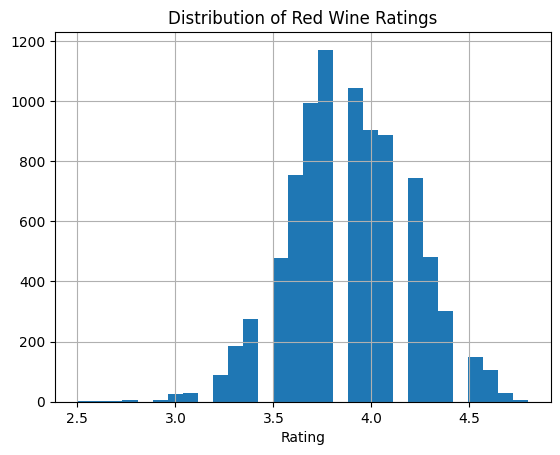

rating
False    0.583891
True     0.416109
Name: proportion, dtype: float64


In [16]:
import matplotlib.pyplot as plt
red_ml_data['rating'].hist(bins=30)
plt.xlabel('Rating')
plt.title('Distribution of Red Wine Ratings')
plt.show()

# check your intended split
print((red_ml_data['rating'] >= 4.0).value_counts(normalize=True))

In [25]:
red_ml_data['year'] = pd.to_numeric(red_ml_data['year'], errors='coerce')
# option A: fill NV wines with the median year
red_ml_data['year'].fillna(red_ml_data['year'].median(), inplace=True)
# option B: drop it entirely if too many nulls
# red_ml_data.drop(columns=['year'], inplace=True)

C:\Users\Beatriz Fernandes\AppData\Local\Temp\ipykernel_10732\1840764672.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  red_ml_data['year'].fillna(red_ml_data['year'].median(), inplace=True)


0       2011.0
1       2017.0
2       2015.0
3       2019.0
4       2016.0
         ...  
8661    2016.0
8662    2016.0
8663    2010.0
8664    2019.0
8665    2016.0
Name: year, Length: 8666, dtype: float64

In [27]:
import numpy as np
red_ml_data['log_price']       = np.log1p(red_ml_data['price'])
red_ml_data['log_num_ratings'] = np.log1p(red_ml_data['numberofratings'])

In [29]:
def keep_top_n(series, n=20):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), other='Other')

red_ml_data['country_clean'] = keep_top_n(red_ml_data['country'], n=20)
red_ml_data['region_clean']  = keep_top_n(red_ml_data['region'],  n=20)

In [31]:
red_ml_data_encoded = pd.get_dummies(red_ml_data, columns=['country_clean'], drop_first=True)

In [33]:
red_ml_data_encoded['is_good'] = (red_ml_data_encoded['rating'] >= 4.0).astype(int)
print(red_ml_data_encoded['is_good'].value_counts(normalize=True))  # check balance!

is_good
0    0.583891
1    0.416109
Name: proportion, dtype: float64


In [34]:
red_ml_data_encoded['value_score'] = red_ml_data_encoded['rating'] / red_ml_data_encoded['price']

In [36]:
from sklearn.preprocessing import StandardScaler

features = ['log_price', 'log_num_ratings', 'year'] + \
           [c for c in red_ml_data_encoded.columns if c.startswith('country_clean_')]

X = red_ml_data_encoded[features]
y = red_ml_data_encoded['is_good']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(classification_report(y_test, lr.predict(X_test)))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1012
           1       0.81      0.72      0.77       722

    accuracy                           0.82      1734
   macro avg       0.81      0.80      0.81      1734
weighted avg       0.82      0.82      0.81      1734



In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83      1012
           1       0.77      0.71      0.74       722

    accuracy                           0.79      1734
   macro avg       0.79      0.78      0.78      1734
weighted avg       0.79      0.79      0.79      1734



In [41]:
from sklearn.model_selection import cross_val_score
cv = cross_val_score(rf, X_test, y_test, cv=5).mean()
print(f'Cross-val accuracy: {cv:.3f}')

Cross-val accuracy: 0.785


In [46]:
red_ml_data_encoded.groupby('country')['value_score'].mean() \
  .sort_values(ascending=False).head(10)

country
Mexico          0.393064
Bulgaria        0.379172
Slovenia        0.331120
Chile           0.310280
Portugal        0.309268
Spain           0.299621
Romania         0.298875
Argentina       0.294070
Hungary         0.282961
South Africa    0.274322
Name: value_score, dtype: float64

In [50]:
"""
Wine Rating Prediction – ML Pipeline
Target: rating | Features: Country, Variety, Winery, Age, log(price), log(numberOfRatings)
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ── 1. Load ──────────────────────────────────────────────────────────────────
print(f"Loaded {red_ml_data.shape[0]:,} rows × {red_ml_data.shape[1]} columns")

# ── 2. Feature Engineering ───────────────────────────────────────────────────
red_ml_data["year_clean"] = pd.to_numeric(red_ml_data["year"], errors="coerce")
red_ml_data["age"] = 2026 - red_ml_data["year_clean"]           # age of the wine
red_ml_data["log_price"] = np.log1p(red_ml_data["price"])       # right-skewed → log transform
red_ml_data["log_ratings"] = np.log1p(red_ml_data["numberofratings"])

df = red_ml_data.dropna(subset=["year_clean"]).copy()
print(f"After cleaning: {df.shape[0]:,} rows")

# ── 3. Encode Categoricals ───────────────────────────────────────────────────
CAT_COLS = ["country", "variety", "winery"]
NUM_COLS = ["age", "log_price", "log_ratings"]

le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

FEATURE_COLS = [c + "_enc" for c in CAT_COLS] + NUM_COLS

X = df[FEATURE_COLS]
y = df["rating"]

# ── 4. Train / Test Split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 5. Models ────────────────────────────────────────────────────────────────
models = {
    "KNN (baseline)": KNeighborsRegressor(n_neighbors=10),
    "Random Forest":  RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
    ),
}

print("\n── Results ──────────────────────────────────────────────────")
print(f"{'Model':<25} {'MAE':>7} {'RMSE':>7} {'R²':>7}")
print("-" * 50)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"{name:<25} {mae:>7.4f} {rmse:>7.4f} {r2:>7.4f}")

# ── 6. Feature Importance (Gradient Boosting) ────────────────────────────────
gb = models["Gradient Boosting"]
fi = pd.Series(gb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\n── Feature Importances (Gradient Boosting) ──────────────────")
for feat, imp in fi.items():
    print(f"  {feat:<20} {imp:.4f}  {'█' * int(imp * 40)}")

print("\nDone. Best model: Gradient Boosting")


Loaded 8,666 rows × 18 columns
After cleaning: 8,658 rows

── Results ──────────────────────────────────────────────────
Model                         MAE    RMSE      R²
--------------------------------------------------
KNN (baseline)             0.2220  0.2791  0.1603
Random Forest              0.1379  0.1788  0.6552
Gradient Boosting          0.1353  0.1768  0.6629

── Feature Importances (Gradient Boosting) ──────────────────
  log_price            0.8386  █████████████████████████████████
  variety_enc          0.0460  █
  country_enc          0.0443  █
  log_ratings          0.0248  
  age                  0.0239  
  winery_enc           0.0224  

Done. Best model: Gradient Boosting


[1] Loaded  →  8,666 rows × 22 columns
[2] After cleaning  →  8,658 rows
[3] Features  →  ['country_enc', 'variety_enc', 'winery_enc', 'age', 'log_price', 'log_ratings']
[4] Train: 6,926  |  Test: 1,732
[5] Model trained

── Test Set Metrics ─────────────────────────────────────────
  MAE   : 0.1381   (avg error in rating points)
  RMSE  : 0.1791
  R²    : 0.6541   (65.4% variance explained)

── 5-Fold CV R² (train set) ─────────────────────────────────
  Scores : [np.float64(0.652), np.float64(0.6292), np.float64(0.6425), np.float64(0.6411), np.float64(0.6052)]
  Mean   : 0.6340  ±  0.0161

── Feature Importances ──────────────────────────────────────
  log_price             0.7103  ███████████████████████████████████
  age                   0.0927  ████
  log_ratings           0.0565  ██
  winery_enc            0.0527  ██
  variety_enc           0.0481  ██
  country_enc           0.0397  █

[8] Plot saved → wine_rf_results.png

Done.


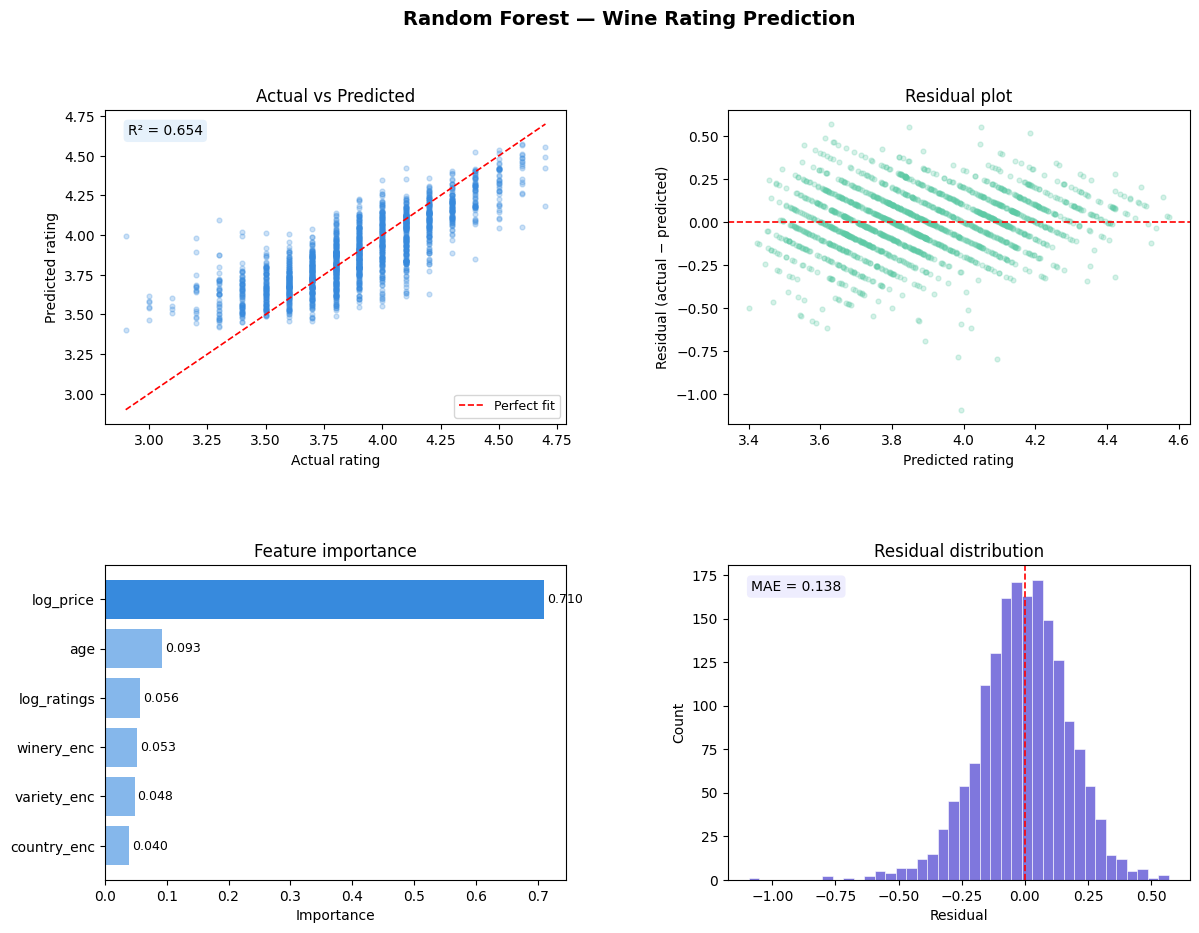

In [53]:
"""
Wine Rating Prediction — Random Forest Pipeline
================================================
Target  : rating (continuous, 2.5 – 4.8)
Features: Country, Variety, Winery, Age (2026 - year),
          log(price), log(numberOfRatings)
"""

# ── 0. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ── 1. Load ───────────────────────────────────────────────────────────────────
FILE = "../data/clean/red_ml_final.csv"

print(f"[1] Loaded  →  {red_ml_data.shape[0]:,} rows × {df.shape[1]} columns")

# ── 2. Feature Engineering ────────────────────────────────────────────────────
df["year_num"]      = pd.to_numeric(df["year"], errors="coerce")
df["age"]           = 2026 - df["year_num"]          # wine age
df["log_price"]     = np.log1p(df["price"])           # fix right skew
df["log_ratings"]   = np.log1p(df["numberofratings"]) # fix right skew

df = df.dropna(subset=["year_num"]).reset_index(drop=True)
print(f"[2] After cleaning  →  {df.shape[0]:,} rows")

# ── 3. Encode Categoricals ────────────────────────────────────────────────────
CAT_COLS = ["country", "variety", "winery"]
NUM_COLS = ["age", "log_price", "log_ratings"]

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

FEATURES = [c + "_enc" for c in CAT_COLS] + NUM_COLS
TARGET   = "rating"

X = df[FEATURES]
y = df[TARGET]

print(f"[3] Features  →  {FEATURES}")

# ── 4. Train / Test Split  (80 / 20) ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"[4] Train: {len(X_train):,}  |  Test: {len(X_test):,}")

# ── 5. Train Random Forest ────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators   = 200,   # number of trees
    max_depth      = 12,    # depth limit (avoids overfitting)
    min_samples_leaf = 5,   # smooth leaf estimates
    max_features   = "sqrt",# standard for regression RF
    random_state   = 42,
    n_jobs         = -1,    # use all cores
)

rf.fit(X_train, y_train)
print("[5] Model trained")

# ── 6. Evaluate ───────────────────────────────────────────────────────────────
y_pred = rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# 5-fold cross-validation R² on training set
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)

print("\n── Test Set Metrics ─────────────────────────────────────────")
print(f"  MAE   : {mae:.4f}   (avg error in rating points)")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}   ({r2*100:.1f}% variance explained)")
print(f"\n── 5-Fold CV R² (train set) ─────────────────────────────────")
print(f"  Scores : {[round(s,4) for s in cv_scores]}")
print(f"  Mean   : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")

# ── 7. Feature Importance ─────────────────────────────────────────────────────
fi = (
    pd.Series(rf.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)
print("\n── Feature Importances ──────────────────────────────────────")
for feat, imp in fi.items():
    bar = "█" * int(imp * 50)
    print(f"  {feat:<20}  {imp:.4f}  {bar}")

# ── 8. Plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Random Forest — Wine Rating Prediction", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# 8a. Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.25, s=12, color="#378ADD")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax1.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")
ax1.set_xlabel("Actual rating")
ax1.set_ylabel("Predicted rating")
ax1.set_title("Actual vs Predicted")
ax1.legend(fontsize=9)
ax1.text(0.05, 0.92, f"R² = {r2:.3f}", transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#E6F1FB", edgecolor="none"))

# 8b. Residuals
residuals = y_test - y_pred
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred, residuals, alpha=0.25, s=12, color="#5DCAA5")
ax2.axhline(0, color="red", linewidth=1.2, linestyle="--")
ax2.set_xlabel("Predicted rating")
ax2.set_ylabel("Residual (actual − predicted)")
ax2.set_title("Residual plot")

# 8c. Feature importance
ax3 = fig.add_subplot(gs[1, 0])
colors = ["#378ADD" if i == 0 else "#85B7EB" for i in range(len(fi))]
bars = ax3.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1], edgecolor="none")
ax3.set_xlabel("Importance")
ax3.set_title("Feature importance")
for bar, val in zip(bars, fi.values[::-1]):
    ax3.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

# 8d. Residual distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals, bins=40, color="#7F77DD", edgecolor="white", linewidth=0.4)
ax4.axvline(0, color="red", linewidth=1.2, linestyle="--")
ax4.set_xlabel("Residual")
ax4.set_ylabel("Count")
ax4.set_title("Residual distribution")
ax4.text(0.05, 0.92, f"MAE = {mae:.3f}", transform=ax4.transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#EEEDFE", edgecolor="none"))

plt.savefig("wine_rf_results.png", dpi=150, bbox_inches="tight")
print("\n[8] Plot saved → wine_rf_results.png")

print("\nDone.")
